In [12]:
import pandas as pd
import pyranges as pr
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from scipy.stats import pearsonr

import seaborn as sns
from goatools.go_enrichment import GOEnrichmentStudy

### Functions def

In [2]:
def load_gtf(gtf_file):
    columns = ["Chromosome", "Source", "Feature", "Start", "End", "Score", "Strand", "Frame", "Attribute"]
    gtf_df = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)
    gtf_df["Chromosome"] = gtf_df["Chromosome"].astype(str)
    gtf_df['Length']=gtf_df['End']-gtf_df['Start']+1
    return gtf_df[["Chromosome", "Feature","Start", "End", "Strand", "Attribute","Length"]]

In [3]:
#compatible with fastaRegexFinder results
def load_motifs(motifs_file):
    columns = ["Chromosome", "Start", "End", "Motif_name", "Strand", "Motif_Matched"]
    motifs_df = pd.read_csv(motifs_file, sep="\t", names=columns)
    motifs_df["second_idx"] = range(1, len(motifs_df) + 1)
    motifs_df["Chromosome"] = motifs_df["Chromosome"].astype(str)
    return motifs_df

In [4]:
def filter_(df,annotation):
    if annotation=='Ensembl':
        resolved_chr = [f'{i}' for i in range(1,25+1)]
        resolved_chr.append('M')
    elif annotation=='Lawson':
        resolved_chr = [f'chr{i}' for i in range(1,25+1)]
        resolved_chr.append('chrM')
    else:
        raise NameError('Not a correct annotation')
        
    return df[df["Chromosome"].isin(resolved_chr)]

### Parameters

In [13]:
case = 'case1' #'case2'
annotation = 'Ensembl' #'Lawson'
#to keep only resolved chromosomes and increase confidence
filter_scaffolds = True #False

In [14]:
if annotation=='Ensembl':
    motifs_file = "../DCM_motifs_in_Genome/Danio_rerio/Ensembl/dcm_motifs_zero_based.bed"
    gtf_file =  "/path_to_Reference/Ensembl/Danio_rerio.GRCz11.113.filtered.gtf"
elif annotation=='Lawson':
    motifs_file = "../DCM_motifs_in_Genome/Danio_rerio/Lawson/dcm_motifs_zero_based.bed"
    gtf_file = "/path_to_Reference/Zebrafish/LawsonData/V4.3.2.validated.gtf" 
else : 
    raise NameError('Not a correct annotation')

#### Initializations

In [15]:
motifs_df = load_motifs(motifs_file)
gtf_df = load_gtf(gtf_file)

if filter_scaffolds:
    motifs_df = filter_(motifs_df,annotation)
    gtf_df = filter_(gtf_df,annotation)

/local/scratch/tmp/ipykernel_359819/2640843344.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  motifs_df = pd.read_csv(motifs_file, sep="\t", names=columns)
/local/scratch/tmp/ipykernel_359819/917124331.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf_df = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)


In [16]:
#case1: consider that a motif also belongs to genes encoded on the complementary strand of that motif
if case=='case1':
    strandedness_=False
#case2: consider a motif only belongs to the genes encoded on its strand
elif case=="case2":
    strandedness_='same'
else:
    raise NameError('Provide a case number')

### Count motifs occurrences per gene

In [17]:
genes=gtf_df[gtf_df["Feature"]=="gene"]
genes['custom_gene_id']=genes['Chromosome'].astype(str) + ':' + genes['Start'].astype(str) + '-' + genes['End'].astype(str) + ':' + genes['Strand'].astype(str)

if annotation=='Ensembl':
    # Keep only the Ensembl ID for downstream
    genes["Attribute"]=genes["Attribute"].str.split('"').str[1]
    genes=genes.rename(columns={"Attribute":"Gene_ID"})
    
genes_ranges =  pr.PyRanges(genes)
motifs_ranges = pr.PyRanges(motifs_df)

inclusion = motifs_ranges.join(genes_ranges, strandedness=strandedness_, how='containment',report_overlap=True)
inclusion = inclusion.df[inclusion.df["Overlap"]>=5]

/local/scratch/tmp/ipykernel_359819/3573918643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes['custom_gene_id']=genes['Chromosome'].astype(str) + ':' + genes['Start'].astype(str) + '-' + genes['End'].astype(str) + ':' + genes['Strand'].astype(str)
/local/scratch/tmp/ipykernel_359819/3573918643.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes["Attribute"]=genes["Attribute"].str.split('"').str[1]


In [18]:
df=inclusion.groupby('custom_gene_id')['second_idx'].nunique().reset_index(name='Motifs_count')
if annotation=='Ensembl':
    gene_motifs_count=genes[['custom_gene_id','Length','Gene_ID']].merge(df, on='custom_gene_id')
if annotation=='Lawson':
    gene_motifs_count=genes[['custom_gene_id','Length']].merge(df, on='custom_gene_id')
gene_motifs_count

,custom_gene_id,Length,Gene_ID,Motifs_count
0,4:1722899-1730920:+,8022,ENSDARG00000009657,12
1,4:11099041-11106856:-,7816,ENSDARG00000096156,16
2,4:40835393-40839221:+,3829,ENSDARG00000076160,22
3,4:30409750-30422325:-,12576,ENSDARG00000117163,34
4,4:11112580-11122638:-,10059,ENSDARG00000096187,24
...,...,...,...,...
24455,25:31099908-31118923:-,19016,ENSDARG00000010844,18
24456,25:16731802-16774774:+,42973,ENSDARG00000115503,130
24457,25:25172983-25176139:+,3157,ENSDARG00000070378,2
24458,25:222921-225964:-,3044,ENSDARG00000110142,10


### Plot

Text(56.472222222222214, 0.5, 'Gene length (=outermost boundaries of its transcripts)')

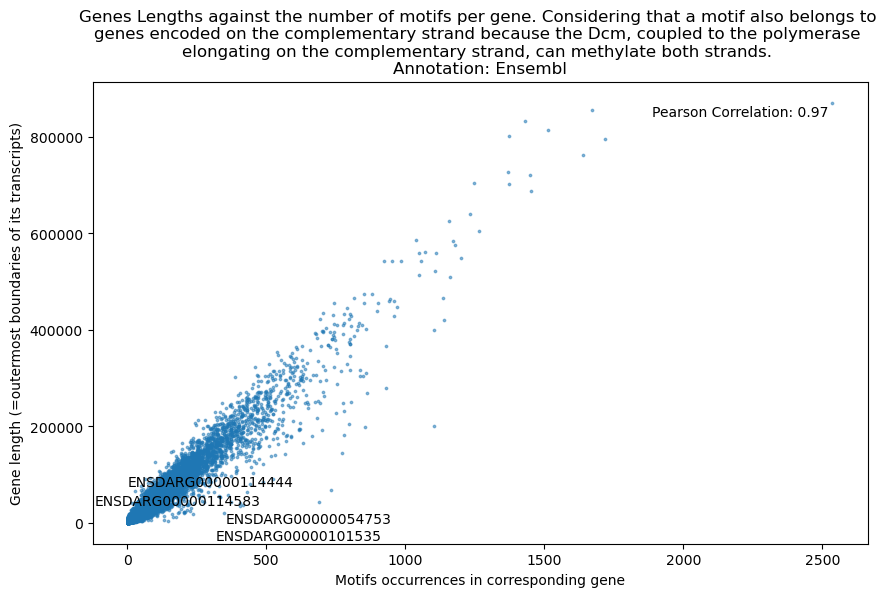

In [19]:
x = gene_motifs_count["Motifs_count"]
y = gene_motifs_count["Length"]


# Define outliers 
high_x_low_y = gene_motifs_count.loc[np.where((x >= np.quantile(x, .75)) & (y <= np.quantile(y, .25)))]
low_x_high_y = gene_motifs_count.loc[np.where((x <= np.quantile(x,0.25)) & (y >= np.quantile(y,.75)))]
outliers = pd.concat([high_x_low_y, low_x_high_y])

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.5, s=3)

if annotation=='Ensembl':
    label_outlier =  'Gene_ID'
elif annotation=='Lawson':
    label_outlier = 'custom_gene_id'
else:
    raise NameError('Provide an annotation')
    
if case=='case1':
    plt.title(f"Genes Lengths against the number of motifs per gene. Considering that a motif also belongs to \ngenes encoded on the complementary strand because the Dcm, coupled to the polymerase \nelongating on the complementary strand, can methylate both strands. \nAnnotation: {annotation}")
if case=='case2':
    plt.title(f"Genes Lengths against the number of motifs per gene. Considering that a motif only belongs to \ngenes encoded on its strand because the Dcm can only methylate motifs found on the strand where the \npolymerase is elongating. \nAnnotation: {annotation}")

# Print correlation on the plot
corr,_ = pearsonr(x,y)
plt.text(0.95, 0.95, 'Pearson Correlation: {:.2f}'.format(corr), 
         transform=plt.gca().transAxes,
         horizontalalignment='right',
         verticalalignment='top')

# Create list to store all text objects
texts = []
for idx, row in outliers.iterrows():
    texts.append(plt.text(row['Motifs_count'], row['Length'], row[f'{label_outlier}'], color='black'))

# Adjust text positions to minimize overlap
adjust_text(texts)


plt.xlabel('Motifs occurrences in corresponding gene')
plt.ylabel('Gene length (=outermost boundaries of its transcripts)')


### GO Analysis

In [23]:
if annotation=='Ensembl':
    genes_to_test = list(outliers['Gene_ID'])
elif annotation=='Lawson':
    genes_to_test = list(outliers['custom_gene_id'])
else:
    raise NameError('Provide an annotation')
genes_to_test

['ENSDARG00000101535',
 'ENSDARG00000054753',
 'ENSDARG00000114583',
 'ENSDARG00000114444']

**Copy paste the genes_to_test to enrichGO notebook written in R and localized in ~/GO/ folder**